# Analysis of global order data with plots  (Done)
1. Compute transition time, sync time and number of transitions/100 iterations  
2. Plot transition time, sync time and number of transitions/100 iterations  
3. Store above parameters as pickle file
4. Note for sync state time

In [1]:
%reload_ext autoreload
%autoreload 2

from tes.data_ingestion import DataRead
from tes.analysis import AnalysisFunc
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import cm
from matplotlib.colors import TwoSlopeNorm
from pathlib import Path
import glob

#### Create objects

In [2]:
reader = DataRead()
analyse = AnalysisFunc()

#### Compute parameters

In [3]:
data_folder = Path("../../data/results/processed/")
# Use glob to match files with a pattern
files = glob.glob(str(data_folder / "itr*.bz2"))

# Initialize a dictionary to store parameter lists
tranPer_params = {}  # to store number of transitions
trans_params = {}  # to store transition times
sync_params = {}  # to store time spent in sync states

for f in files:
    # Extract the part of the filename after the underscore
    file_stem = Path(f).stem  # e.g., "itr_bla"
    name_suffix = file_stem.split("_")[1]  # e.g., "bla"
    df_d = pd.read_pickle(f, compression="bz2")

    # Compute parameters
    params = analyse.compute_param(df_d, 0.05)

    # Store lists in the dictionary
    tranPer_params[f"{name_suffix}"] = params["tran_per"]
    trans_params[f"{name_suffix}"] = params["trans"]
    sync_params[f"{name_suffix}"] = params["sync"]

Number of transitions / 100 iteration [0, 37, 76, 110, 146, 178, 211, 255, 287, 324, 359]
Number of transition [6, 7, 12, 22, 23, 26, 27, 29, 30, 35, 37, 43, 44, 47, 48, 54, 57, 59, 62, 63, 64, 66, 67, 69, 73, 78, 79, 85, 92, 93, 98, 104, 106, 109, 110, 112, 115, 117, 121, 125, 130, 134, 135, 141, 142, 145, 148, 149, 151, 156, 158, 159, 162, 166, 168, 172, 173, 177, 180, 181, 182, 184, 187, 191, 192, 193, 197, 198, 210, 211, 214, 218, 223, 224, 226, 227, 228, 229, 232, 237, 239, 245, 246, 247, 250, 258, 262, 264, 274, 281, 283, 295, 296, 297, 298, 303, 305, 314, 320, 322, 326, 328, 329, 333, 334, 336, 342, 343, 345, 347, 348, 350, 351, 356, 359, 360, 365, 368, 370, 371, 375, 378, 382, 384, 385, 392, 395, 396, 397, 399, 402, 410, 412, 414, 416, 424, 425, 426, 430, 431, 439, 443, 451, 454, 455, 456, 460, 465, 470, 474, 476, 482, 484, 492, 498, 501, 502, 504, 505, 506, 508, 509, 511, 512, 514, 520, 531, 533, 536, 563, 566, 568, 574, 576, 582, 587, 588, 589, 593, 595, 597, 599, 601, 602, 6

#### Plot parameters

In [4]:
node_order = np.array(["fn", "bla", "enti", "orbi", "peri", "pir", "re"])
# sort node order in descending order according to number of transitions (keeping 'fn' on top)
non = np.r_[np.argsort([tranPer_params[k][-1] / 1000 for k in node_order[1:]]) + 1, 0]
non

array([4, 1, 2, 5, 3, 6, 0])

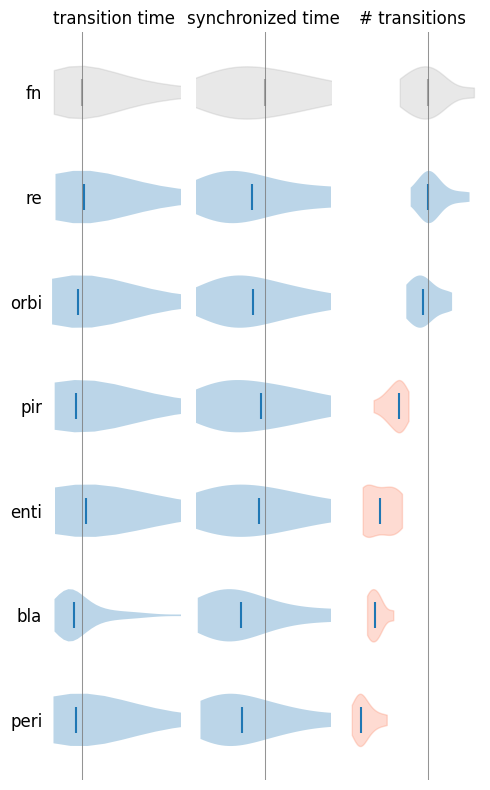

In [5]:
f, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(5, 8), sharey=True)

_artists = ax1.violinplot(
    [trans_params[k] for k in node_order[non]],
    vert=False,
    showextrema=False,
    showmedians=True,
)
ax1.set_yticks(np.arange(1, len(node_order) + 1))
ax1.set_yticklabels(node_order[non], fontsize=12)
_artists["bodies"][-1].set_color(cm.Greys(0.4, 0.4))
_artists["cmedians"].set_color(
    list(_artists["cmedians"].get_color()) * 6 + [cm.Greys(0.8, 0.4)]
)
ax1.spines[["left", "right", "top", "bottom"]].set_visible(False)
ax1.set_xticks([])
ax1.set_xlim(20, 100)
ax1.tick_params(axis="both", which="both", length=0)
ax1.set_title("transition time")
ax1.axvline(np.median(trans_params["fn"]), c=cm.Greys(0.6, 0.8), lw=0.75)

_artists = ax2.violinplot(
    [sync_params[k] for k in node_order[non]],
    vert=False,
    showextrema=False,
    showmedians=True,
)
# ax2.set_yticks(np.arange(1, len(node_order)+1))
# ax1.set_yticklabels(node_order)
_artists["bodies"][-1].set_color(cm.Greys(0.4, 0.4))
_artists["cmedians"].set_color(
    list(_artists["cmedians"].get_color()) * 6 + [cm.Greys(0.8, 0.4)]
)
ax2.spines[["left", "right", "top", "bottom"]].set_visible(False)
ax2.set_xticks([])
ax2.set_xlim(80, 500)
ax2.tick_params(axis="both", which="both", length=0)
ax2.set_title("synchronized time")
ax2.axvline(np.median(sync_params["fn"]), c=cm.Greys(0.6, 0.8), lw=0.75)

_artists = ax3.violinplot(
    [np.diff(np.array(tranPer_params[k])) for k in node_order[non]],
    vert=False,
    showextrema=False,
    showmedians=True,
)
# ax3.set_yticks(np.arange(1, len(node_order)+1))
# ax3.set_yticklabels(node_order)
_artists["bodies"][-1].set_color(cm.Greys(0.4, 0.4))
for i in range(4):
    _artists["bodies"][i].set_color(cm.Reds(0.4, 0.4))
_artists["cmedians"].set_color(
    list(_artists["cmedians"].get_color()) * 6 + [cm.Greys(0.8, 0.4)]
)
ax3.spines[["left", "right", "top", "bottom"]].set_visible(False)
ax3.set_xticks([])
# ax3.set_xlim(80, 500)
ax3.tick_params(axis="both", which="both", length=0)
ax3.set_title("# transitions")
ax3.axvline(np.median(np.diff(tranPer_params["fn"])), c=cm.Greys(0.6, 0.8), lw=0.75)


f.subplots_adjust(wspace=0.8)
f.tight_layout()

### Note: 
In above plot, 'synchronized time' is ambiguous. It considers only the transitions where there is fallback. We also need to consider the synchronized time for transitions in which there is no fallback. See notebook: Analyse Sync State Time.ipynb


#### Store above data

In [6]:
reader.data_dump_pkl("results/nTrans_data.pkl", tranPer_params)
reader.data_dump_pkl("results/trans_data.pkl", trans_params)
# reader.data_dump_pkl("results/sync_data.pkl", sync_params)